# Determinants of Heating Load in Residential Building Design
**Name**:  Jerik Adrian Valencia BAYON <br>
**Student Number**:  6530363577

## Overview
___

### Purpose:
* Estimate how residential building design features predict **heating load** (DV) using **768** simulated building designs. 
* Building design features (IV) include the following:
  - **relative compactness:** how “cube-like” or compact the building shape is
  - **surface area:** total exterior area exposed to outside air
  - **wall area:** total area of external walls
  - **roof area:** total roof area
  - **overall height:** building height
  - **orientation:** direction the building faces
  - **glazing area:** amount of window area
  - **glazing area distribution:** window placement


### Dataset source:
- Dataset: [Energy Efficiency (UCI Machine Learning Repository)](https://archive.ics.uci.edu/dataset/242/energy+efficiency)
- Prior work: Tsanas & Xifara (2012).

#### Reference
Tsanas, A., & Xifara, A. (2012). *Accurate quantitative estimation of energy performance of residential buildings using statistical machine learning tools.* Energy and Buildings, 49, 560–567. https://doi.org/10.1016/j.enbuild.2012.03.003


## Descriptive Statistics
___

The analysis begins with a dispersion summary to characterize variability and motivate which variables to prioritize in later analyses.

In [1]:
%%capture
%run parse_data.py
%run -i descriptive.py

In [2]:
display_dispersion_table(num=1)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Dispersion summary statistics</span></p>

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load
st.dev.,0.1057,88.0,43.6,45.1,1.75,1.1,0.13,1.5,10.08
min,0.6200,514.5,245.0,110.2,3.50,2.0,0.00,0.0,6.01
max,0.9800,808.5,416.5,220.5,7.00,5.0,0.40,5.0,43.10
range,0.3600,294.0,171.5,110.2,3.50,3.0,0.40,5.0,37.09
25th,0.6825,606.4,294.0,140.9,3.50,2.8,0.10,1.8,12.99
75th,0.8300,741.1,343.0,220.5,7.00,4.2,0.40,4.0,31.67
IQR,0.1475,134.8,49.0,79.6,3.50,1.5,0.30,2.2,18.68


Results from Table 1 shows:

* Heating load varies widely (min ≈ 6.0, max ≈ 43.1; SD ≈ 10.1), so there is meaningful outcome variation for analysis.
* Overall height takes only a small number of distinct values, and quartiles jump between them; the data may naturally split into height regimes.
* Several features span wide numeric ranges (surface area, wall area, roof area), which could meaningfully shift heating load.
* There is a large scale difference across the building design features, which may affect further analysis.

Next, scatterplots for continuous variables, and boxplots for categorical variables, are used to screen for strong associations with heating load, and to flag building design features with minimal apparent effect.

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Descriptive plots for building design features</span></p><br><br>

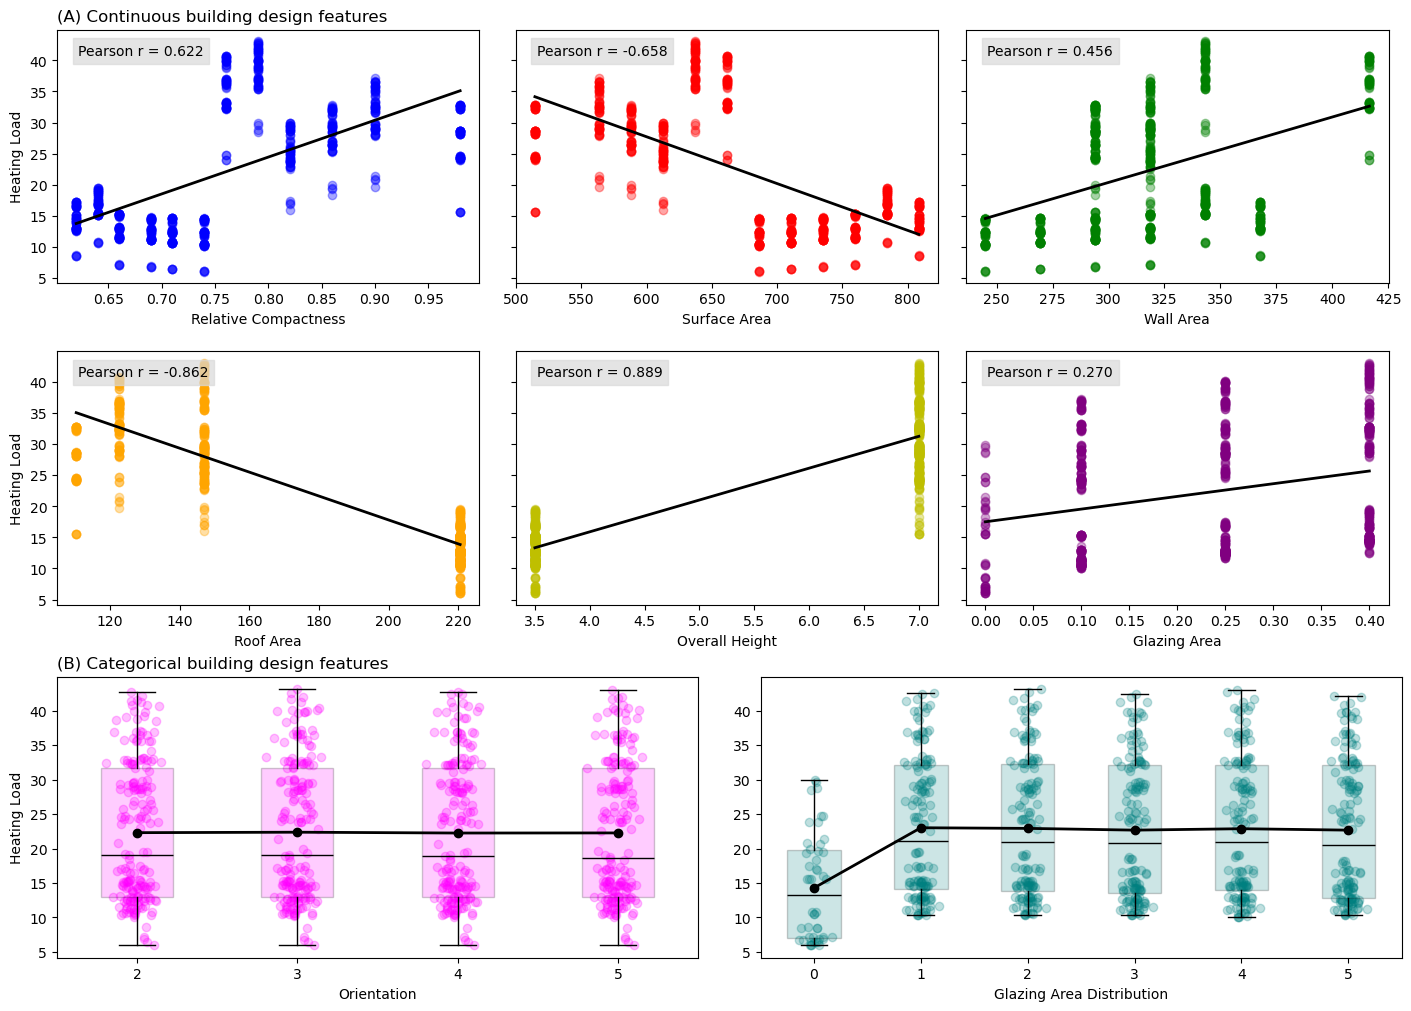

In [3]:
plot_descriptive(num=1)

Results from Figure 1 shows:

* The large heating load spread noted in Table 1 is reflected here by strong upward/downward trends in several continuous building design features, indicating substantial explainable variation rather than noise.
* As for the strongest continuous relationships, heating load increases with overall height (r ≈ 0.889), and relative compactness (r ≈ 0.622), and decreases with roof area (r ≈ −0.862), and surface area (r ≈ −0.658).
* Wall area shows a moderate positive association (r ≈ 0.456), while glazing area is weakly related (r ≈ 0.270), suggesting glazing area alone is a smaller driver than geometry/size building design features.
* As assumed in Table 1, height regimes can be observed as shown by the scatter's two separated clusters at 3.5 and 7.0.
* Orientation shows little separation across categories (boxplots overlap heavily), implying a comparatively small effect on heating load.
* Glazing area distribution shows a noticeable jump from category 0 to higher categories, but differences among categories 1–5 are relatively small.

## Hypothesis Testing
___

Descriptive statistics suggest specific unique traits of the dataset:

* Height has the strongest correlation among the building design features, and despite being a continuous variable, it only has two levels (3.5 and 7.0).
* Among the continuous building design features, glazing area shows the weakest correlation when viewed in aggregate.
* Glazing area distribution has a distinctive 0 vs non-0 structure.

With this, hypothesis testing was done in order to formally verify whether these patterns represent real differences in heating load rather than random variation, and to test whether important relationships are being masked when the height regimes are pooled together. First, a simple linear regression was run separately within each height regime (heating load vs. glazing area) and the slopes were compared, testing whether glazing area has a different effect on heating load for low-height versus high-height buildings. 

<p><span style="font-size: 1.2em;"><b>Figure 2</b>: Heating load vs glazing area by height (3.5 and 7.0)</span></p><br><br>

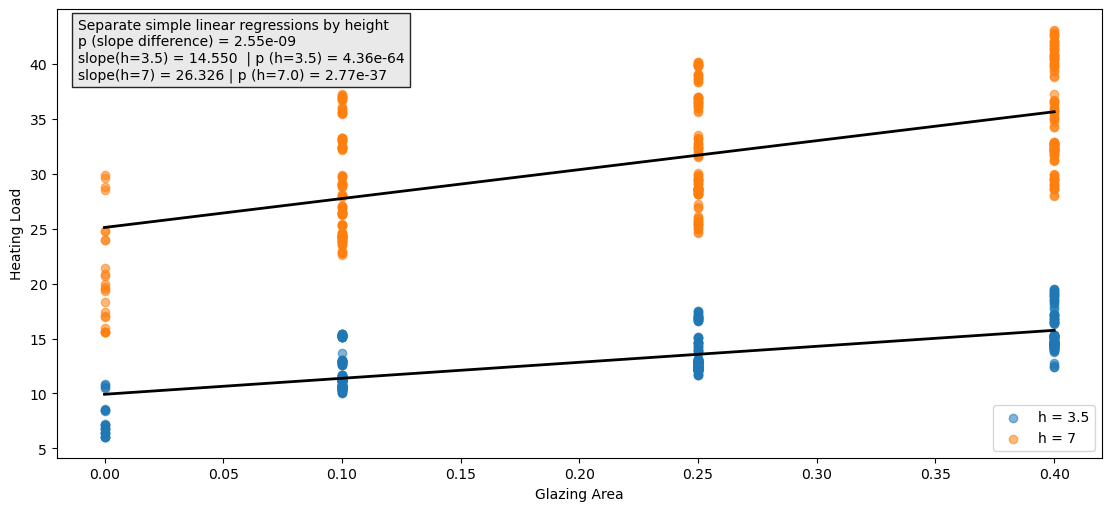

In [4]:
%run -i classical.py
plot_hypothesis1(num=2)

Results from Figure 2 shows:

* Clear height regimes observed as heating load clusters into two, h = 3.5 (lower heating loads) and h = 7.0 (higher heating loads).
* Positive glazing area effect within each height regime can be seen as the fitted line slopes upward in both height groups. 
* Effect is stronger at taller height (h = 7.0 ≈ 26.33 vs. h = 3.5 ≈ 14.55), indicating glazing area impacts heating load more strongly in taller buildings.
* The slope difference test shows p ≈ 2.55×10⁻⁹, meaning the difference in glazing area slopes across heights is significant (p < 0.05).
* Height changes the glazing area  and heating load relationship, so pooling both heights can hide the true glazing area effect.

Next, a two-sample t-test compared mean heating load between buildings with glazing area distribution = 0 and glazing area distribution ≠ 0, testing whether “no glazing area distribution” is associated with a statistically different heating-load level than “some glazing area distribution.”

In [ ]:
plot_hypothesis2(num=3)

<p><span style="font-size: 1.2em;"><b>Figure 3</b>: Glazing area distribution (0 vs non-0) and heating load</span></p><br><br>

Results from Figure 3 shows:

* The median heating load is much higher for glazing area distribution ≠ 0 than for glazing area distribution = 0, indicating a strong difference in typical heating demand.
* The two-sample t-test gives p = 6.98×10⁻¹⁰, so the mean heating loads of the two groups are significantly different (p < 0.05).
* Having a non-0 glazing area distribution is associated with higher and more variable heating load.

## Machine Learning
___

Descriptive statistics showed large scale differences among the building design features and clear clustering by height, while the hypothesis tests confirmed that overall height creates two distinct regimes (h = 3.5 and 7.0) that can change how other features (e.g., glazing area) relate to heating load. With these patterns established, machine learning was used as a predictive check to see whether the full set of building design features can accurately predict heating load. Two regression models were compared: KNN, which predicts heating load from the outcomes of the most similar buildings in feature space (distance-based), and SVR, which learns a flexible nonlinear relationship (kernel-based) that balances fit and generalization. Because KNN and SVR learn in fundamentally different ways (local similarity vs global function), consistent results across both strengthen confidence that performance patterns reflect the data structure rather than a single model choice.

Model performance was evaluated using a held-out test set, wherein each model was trained on the training split and then assessed on unseen test data using R², RMSE, and MAE. R² measures how much of the variation in heating load is explained by the model (higher is better). RMSE is the typical error magnitude but penalizes large mistakes more strongly (lower is better). MAE is the average absolute prediction error in the same units as heating load (lower is better).

Having mixed feature types (continuous + categorical) and large scale differences across predictors can noticeably affect model performance. For that reason, preprocessing was applied, specifically scaling and encoding, to transform the raw inputs into a form the models can use fairly. Scaling places continuous variables (e.g., surface area, wall area, roof area) onto comparable ranges so distance-based KNN is not dominated by large-magnitude features and SVR’s kernel is not distorted by unequal feature scales. Encoding converts categorical predictors (e.g., orientation, glazing distribution) into numeric representations  so models do not incorrectly treat category labels as meaningful ordered distances. Together, these steps reduce representation bias across features and can improve predictive accuracy.

In [ ]:
%run -i improved_machine.py
plot_ml_figure4(num=4)

Results from Figure 4 shows:

* After preprocessing, both the KNN and SVR model improved as shown by the increased R² value, and lower RMSE and MAE score.
* Before preprocessing, the KNN model performed best, but after preprocessing, the SVR model improved significantly and predicts slightly better than the KNN model, indicating that the SVR model gained more from preprocessing over KNN.

Other than the overall model perfomance, the model performance within the 2 height regimes was tested because overall height is a dominant driver of heating load. This creates two clusters with different heating-load ranges, so evaluating them separately checks whether the model generalizes consistently across height regimes and whether important relationships (e.g., glazing area effects) are being masked when both heights are pooled into a single overall metric.

In [ ]:
plot_ml_figure5(num=5)

Results from Figure 5 shows:

* The SVR model performed best for both height regimes as shown by the higher R² value, and lower RMSE and MAE score.
* Both KNN and SVR models perform better at h = 3.5.
* Model accuracy is height dependent, so pooling heights would hide that tall buildings are predicted with larger uncertainty.

## Summary
___

This project predicts heating load of residential buildings using 768 simulated building designs and eight design features. Descriptive statistics show heating load varies a lot and the dataset has unique traits: features are on very different scales, height has only two values (3.5 vs 7.0), and glazing distribution has a clear 0 vs non-0 split. Hypothesis tests confirm these patterns. The glazing area and heating load relationship differs between the two height groups, and heating load is significantly different for glazing area distribution = 0 vs ≠ 0. Finally, machine learning through KNN and SVR tests overall model prediction accuracy. Preprocessing through scaling and encoding improves performance of both models, specifically for SVR. When the model performace was separated across the 2 height regimes, the results show that both the KNN and SVR models predict better for lower height buildings. Overall, the results show that building geometry, especially height, dominates heating-load behavior, and that handling scale and categorical structure properly is key for making reliable predictions.